# PINN Dynamics Model Training Auto v5.2

This notebook trains a JSBSim-based 2D longitudinal PINN with explicit rollout accuracy in mind.

Changes from v5.1:
- Uses a warm-start elevator command before collecting training rows
- Aligns data collection, JSBSim rollout validation, and PINN rollout with the same elevator-history contract
- Keeps safer rollout-loss training and best-checkpoint auto-training restart
- Uses augmented inputs: `[h, V, theta, q, elevator, prev_elevator, delevator]`

## 0. Install & Imports

In [1]:
!pip install jsbsim optuna -q
print('Install complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.5 MB/s eta 0:00:00
Install complete


In [2]:
import os, json, time, random, warnings
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DEFAULT_SAVE_DIR = '/content/drive/MyDrive/PINN_MODEL_ONLY_v1'
except Exception:
    DEFAULT_SAVE_DIR = './PINN_MODEL_ONLY_v1'

SAVE_DIR = DEFAULT_SAVE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
Device: cpu


## 1. Configuration

Use `FAST_MODE=True` for quick experiments. Switch to `FAST_MODE=False` only when training a final model.

In [3]:
FAST_MODE = True
USE_OPTUNA = False

INIT_ALT = 3000.0
THROTTLE = 0.85
DT = 0.02

STATE_COLS = ['h', 'V', 'theta', 'q']
INPUT_COLS = ['elevator', 'prev_elevator', 'delevator']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq']

if FAST_MODE:
    N_EPISODES = 45
    N_STEPS = 900
    EPOCHS = 320
    BATCH_SIZE = 1024
    HIDDEN_DIM = 160
    N_LAYERS = 4
    N_TRIALS = 5
    ROLLOUT_STEPS = 180
    N_ROLLOUT_VAL_CASES = 8
    N_ROLLOUT_TEST_CASES = 8
    SEQ_WINDOW = 18
    SEQ_STRIDE = 4
    SEQ_BATCH_SIZE = 96
else:
    N_EPISODES = 180
    N_STEPS = 1400
    EPOCHS = 950
    BATCH_SIZE = 1024
    HIDDEN_DIM = 224
    N_LAYERS = 5
    N_TRIALS = 20
    ROLLOUT_STEPS = 350
    N_ROLLOUT_VAL_CASES = 16
    N_ROLLOUT_TEST_CASES = 16
    SEQ_WINDOW = 28
    SEQ_STRIDE = 5
    SEQ_BATCH_SIZE = 128

LR = 6e-4
WEIGHT_DECAY = 1e-6
LAM_PHYSICS = 0.10
LAM_SMOOTH = 0.0005
LAM_ROLLOUT = 0.10
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# One-step target weights. Order: [dh, dV, dtheta, dq]
TARGET_WEIGHTS = [1.0, 1.0, 2.0, 8.0]

# Recursive rollout state weights. Order: [h, V, theta, q]
ROLLOUT_STATE_WEIGHTS = [1.0, 0.4, 3.0, 6.0]
ROLLOUT_STATE_SCALES = [5.0, 2.0, 0.02, 0.04]

# Automatic continued-training settings.
AUTO_TRAIN = True
AUTO_MAX_CYCLES = 8 if FAST_MODE else 12
AUTO_CHUNK_EPOCHS = 120 if FAST_MODE else 200
AUTO_LR_DECAY = 0.72

# Rollout targets. q is measured in rad/s.
TARGET_H_RMSE_FT = 1.5 if FAST_MODE else 0.8
TARGET_THETA_RMSE_RAD = 0.025 if FAST_MODE else 0.015
TARGET_Q_RMSE_RAD_S = 0.045 if FAST_MODE else 0.025

ROLLOUT_VAL_SEED = SEED + 1000
ROLLOUT_TEST_SEED = SEED + 2000

DATA_INPUT_ALIGNMENT = 'current_elevator_command'
MODEL_INPUT_CONTRACT = 'state_plus_elevator_history'
TRAINING_CONTRACT = 'one_step_plus_short_recursive_rollout_loss_warmstart_aligned_v5_2'

CONFIG = dict(
    FAST_MODE=FAST_MODE, USE_OPTUNA=USE_OPTUNA, INIT_ALT=INIT_ALT,
    THROTTLE=THROTTLE, DT=DT, N_EPISODES=N_EPISODES, N_STEPS=N_STEPS,
    EPOCHS=EPOCHS, BATCH_SIZE=BATCH_SIZE, HIDDEN_DIM=HIDDEN_DIM,
    N_LAYERS=N_LAYERS, LR=LR, LAM_PHYSICS=LAM_PHYSICS,
    LAM_SMOOTH=LAM_SMOOTH, LAM_ROLLOUT=LAM_ROLLOUT,
    ROLLOUT_STEPS=ROLLOUT_STEPS, SEQ_WINDOW=SEQ_WINDOW,
    SEQ_STRIDE=SEQ_STRIDE, SEQ_BATCH_SIZE=SEQ_BATCH_SIZE,
    N_ROLLOUT_VAL_CASES=N_ROLLOUT_VAL_CASES,
    N_ROLLOUT_TEST_CASES=N_ROLLOUT_TEST_CASES,
    TARGET_WEIGHTS=TARGET_WEIGHTS,
    ROLLOUT_STATE_WEIGHTS=ROLLOUT_STATE_WEIGHTS,
    ROLLOUT_STATE_SCALES=ROLLOUT_STATE_SCALES,
    AUTO_TRAIN=AUTO_TRAIN, AUTO_MAX_CYCLES=AUTO_MAX_CYCLES,
    AUTO_CHUNK_EPOCHS=AUTO_CHUNK_EPOCHS,
    TARGET_H_RMSE_FT=TARGET_H_RMSE_FT,
    TARGET_THETA_RMSE_RAD=TARGET_THETA_RMSE_RAD,
    TARGET_Q_RMSE_RAD_S=TARGET_Q_RMSE_RAD_S,
    ROLLOUT_VAL_SEED=ROLLOUT_VAL_SEED,
    ROLLOUT_TEST_SEED=ROLLOUT_TEST_SEED,
    DATA_INPUT_ALIGNMENT=DATA_INPUT_ALIGNMENT,
    MODEL_INPUT_CONTRACT=MODEL_INPUT_CONTRACT,
    WARMSTART_ELEVATOR_ALIGNMENT=True,
    TRAINING_CONTRACT=TRAINING_CONTRACT,
)
print(json.dumps(CONFIG, indent=2))

{
  "FAST_MODE": true,
  "USE_OPTUNA": false,
  "INIT_ALT": 3000.0,
  "THROTTLE": 0.85,
  "DT": 0.02,
  "N_EPISODES": 45,
  "N_STEPS": 900,
  "EPOCHS": 320,
  "BATCH_SIZE": 1024,
  "HIDDEN_DIM": 160,
  "N_LAYERS": 4,
  "LR": 0.0006,
  "LAM_PHYSICS": 0.1,
  "LAM_SMOOTH": 0.0005,
  "LAM_ROLLOUT": 0.1,
  "ROLLOUT_STEPS": 180,
  "SEQ_WINDOW": 18,
  "SEQ_STRIDE": 4,
  "SEQ_BATCH_SIZE": 96,
  "N_ROLLOUT_VAL_CASES": 8,
  "N_ROLLOUT_TEST_CASES": 8,
  "TARGET_WEIGHTS": [
    1.0,
    1.0,
    2.0,
    8.0
  ],
  "ROLLOUT_STATE_WEIGHTS": [
    1.0,
    0.4,
    3.0,
    6.0
  ],
  "ROLLOUT_STATE_SCALES": [
    5.0,
    2.0,
    0.02,
    0.04
  ],
  "AUTO_TRAIN": true,
  "AUTO_MAX_CYCLES": 8,
  "AUTO_CHUNK_EPOCHS": 120,
  "TARGET_H_RMSE_FT": 1.5,
  "TARGET_THETA_RMSE_RAD": 0.025,
  "TARGET_Q_RMSE_RAD_S": 0.045,
  "ROLLOUT_VAL_SEED": 1042,
  "ROLLOUT_TEST_SEED": 2042,
  "DATA_INPUT_ALIGNMENT": "current_elevator_command",
  "MODEL_INPUT_CONTRACT": "state_plus_elevator_history",
  "WARMSTART_ELEVAT

## 2. JSBSim Helpers

In [4]:
def make_fdm(init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    return fdm


def read_state(fdm):
    return np.array([
        fdm['position/h-sl-ft'],
        fdm['velocities/vt-fps'],
        fdm['attitude/theta-rad'],
        fdm['velocities/q-rad_sec'],
    ], dtype=np.float32)


def is_valid_state(s):
    h, V, theta, q = s[:4]
    return 100.0 < h < 30000.0 and 40.0 < V < 1200.0 and abs(theta) < 1.2 and abs(q) < 3.0


print('JSBSim helpers ready')

JSBSim helpers ready


## 3. Data Collection

The elevator input uses a mixture of smooth random, sine, step, and chirp excitation. This improves rollout robustness compared with training on random inputs only.

In [5]:
def make_elevator_signal(n_steps, mode):
    t = np.arange(n_steps) * DT
    if mode == 'smooth_random':
        elev = np.zeros(n_steps, dtype=np.float32)
        for i in range(1, n_steps):
            elev[i] = 0.94 * elev[i-1] + 0.06 * np.random.uniform(-0.45, 0.45)
        return np.clip(elev, -0.45, 0.45)
    if mode == 'sine':
        amp = np.random.uniform(0.08, 0.28)
        freq = np.random.uniform(0.03, 0.18)
        phase = np.random.uniform(0, 2*np.pi)
        return (amp * np.sin(2*np.pi*freq*t + phase)).astype(np.float32)
    if mode == 'steps':
        elev = np.zeros(n_steps, dtype=np.float32)
        hold = np.random.randint(25, 100)
        val = 0.0
        for i in range(n_steps):
            if i % hold == 0:
                val = np.random.uniform(-0.40, 0.40)
                hold = np.random.randint(25, 120)
            elev[i] = val
        return elev
    if mode == 'chirp':
        amp = np.random.uniform(0.08, 0.26)
        f0, f1 = 0.03, np.random.uniform(0.18, 0.45)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return (amp * np.sin(phase)).astype(np.float32)
    if mode == 'doublet':
        elev = np.zeros(n_steps, dtype=np.float32)
        k = np.random.randint(30, max(31, n_steps - 120))
        amp = np.random.uniform(0.15, 0.35) * np.random.choice([-1.0, 1.0])
        width = np.random.randint(12, 35)
        elev[k:k+width] = amp
        elev[k+width:k+2*width] = -amp
        return elev
    raise ValueError(mode)


def collect_episodes(n_episodes=N_EPISODES, n_steps=N_STEPS, verbose=True):
    rows = []
    modes = ['smooth_random', 'sine', 'steps', 'chirp', 'doublet']
    for ep in range(n_episodes):
        init_alt = np.random.uniform(1800, 7500)
        init_speed = np.random.uniform(75, 125)
        init_pitch = np.random.uniform(-8, 12)
        mode = modes[ep % len(modes)]
        elev_seq = make_elevator_signal(n_steps, mode)

        fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)

        # Warm-start with the first command so JSBSim internal state, prev_elevator,
        # and the first supervised row all follow the same input-history contract.
        prev_elev = float(elev_seq[0])
        fdm['fcs/elevator-cmd-norm'] = prev_elev
        fdm.run()
        prev_state = read_state(fdm)

        for k in range(1, n_steps):
            current_elev = float(elev_seq[k])
            delevator = current_elev - prev_elev

            fdm['fcs/elevator-cmd-norm'] = current_elev
            fdm.run()
            state = read_state(fdm)

            if is_valid_state(prev_state) and is_valid_state(state):
                delta = state - prev_state
                rows.append({
                    'episode': ep, 'step': k - 1, 'mode': mode,
                    'h': prev_state[0], 'V': prev_state[1],
                    'theta': prev_state[2], 'q': prev_state[3],
                    'elevator': current_elev,
                    'prev_elevator': prev_elev,
                    'delevator': delevator,
                    'dh': delta[0], 'dV': delta[1],
                    'dtheta': delta[2], 'dq': delta[3],
                })

            prev_state = state
            prev_elev = current_elev

        if verbose and ((ep + 1) % 5 == 0 or ep == 0):
            print(f'episode {ep+1:3d}/{n_episodes} | rows={len(rows):,} | mode={mode}')

    return pd.DataFrame(rows)


df_all = collect_episodes()
print(df_all.shape)
df_all.head()



     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

episode   1/45 | rows=899 | mode=smooth_random
episode   5/45 | rows=4,495 | mode=doublet
episode  10/45 | rows=8,990 | mode=doublet
episode  15/45 | rows=13,485 | mode=doublet
episode  20/45 | rows=17,980 | mode=doublet
episode  25/45 | rows=22,475 | mode=doublet
episode  30/45 | rows=26,970 | mode=doublet
episode  35/45 | rows=31,465 | mode=doublet
episode  40/45 | rows=35,960 | mode=doublet
episode  45/45 | rows=40,455 | mode=doublet
(40455, 14)


,episode,step,mode,h,V,theta,q,elevator,prev_elevator,delevator,dh,dV,dtheta,dq
0,0,0,smooth_random,3935.077881,206.749939,0.115888,0.025082,0.005328,0.000000,0.005328,0.199463,-0.067017,0.000209,0.024235
1,0,1,smooth_random,3935.277344,206.682922,0.116097,0.049316,-0.013567,0.005328,-0.018895,0.199463,-0.067307,0.000411,0.022285
2,0,2,smooth_random,3935.476807,206.615616,0.116508,0.071601,-0.031329,-0.013567,-0.017762,0.199463,-0.067795,0.000597,0.023242
3,0,3,smooth_random,3935.676270,206.547821,0.117105,0.094843,-0.053313,-0.031329,-0.021984,0.199707,-0.068710,0.000790,0.024062
4,0,4,smooth_random,3935.875977,206.479111,0.117895,0.118905,-0.030341,-0.053313,0.022972,0.199707,-0.069733,0.000991,0.025316


In [6]:
csv_path = os.path.join(SAVE_DIR, 'dataset_jsbsim_c172_2d.csv')
df_all.to_csv(csv_path, index=False)
print('Saved dataset:', csv_path)
print(df_all.groupby('mode').size())

Saved dataset: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/dataset_jsbsim_c172_2d.csv
mode
chirp            8091
doublet          8091
sine             8091
smooth_random    8091
steps            8091
dtype: int64


## 4. Episode-Level Split & Normalization

In [7]:
def split_by_episode(df, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO):
    episodes = np.array(sorted(df['episode'].unique()))
    rng = np.random.default_rng(SEED)
    rng.shuffle(episodes)

    n = len(episodes)
    n_test = max(1, int(round(n * test_ratio)))
    n_val = max(1, int(round(n * val_ratio)))
    test_eps = set(episodes[:n_test])
    val_eps = set(episodes[n_test:n_test+n_val])
    train_eps = set(episodes[n_test+n_val:])

    train_df = df[df['episode'].isin(train_eps)].reset_index(drop=True)
    val_df = df[df['episode'].isin(val_eps)].reset_index(drop=True)
    test_df = df[df['episode'].isin(test_eps)].reset_index(drop=True)
    return train_df, val_df, test_df, train_eps, val_eps, test_eps


train_df, val_df, test_df, train_eps, val_eps, test_eps = split_by_episode(df_all)
print('episodes train/val/test:', len(train_eps), len(val_eps), len(test_eps))
print('rows train/val/test:', len(train_df), len(val_df), len(test_df))


def make_stats(train_df):
    X = torch.tensor(train_df[FEAT_COLS].values, dtype=torch.float32)
    Y = torch.tensor(train_df[TGT_COLS].values, dtype=torch.float32)
    return {
        'Xm': X.mean(0),
        'Xs': X.std(0).clamp_min(1e-8),
        'Ym': Y.mean(0),
        'Ys': Y.std(0).clamp_min(1e-8),
    }


stats = make_stats(train_df)
for k, v in stats.items():
    print(k, v.numpy())

episodes train/val/test: 31 7 7
rows train/val/test: 27869 6293 6293
Xm [ 4.0229285e+03  1.3696819e+02  1.7528152e-01  1.2961923e-02
  7.9855497e-04  8.8256737e-04 -8.4012274e-05]
Xs [1.40313330e+03 2.42754612e+01 2.01043978e-01 1.20833516e-01
 1.51757196e-01 1.51727408e-01 2.41947044e-02]
Ym [ 1.2918445e-01 -6.0140342e-02  9.0738336e-05 -8.2331127e-05]
Ys [0.21252452 0.05270649 0.00101068 0.00443789]


In [8]:
class DynamicsDataset(torch.utils.data.Dataset):
    def __init__(self, df, stats):
        X = torch.tensor(df[FEAT_COLS].values, dtype=torch.float32)
        Y = torch.tensor(df[TGT_COLS].values, dtype=torch.float32)
        self.X = (X - stats['Xm']) / stats['Xs']
        self.Y = (Y - stats['Ym']) / stats['Ys']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class SequenceDataset(torch.utils.data.Dataset):
    def __init__(self, df, window=SEQ_WINDOW, stride=SEQ_STRIDE):
        self.items = []
        for _, g in df.sort_values(['episode', 'step']).groupby('episode'):
            states = g[STATE_COLS].values.astype(np.float32)
            inputs = g[INPUT_COLS].values.astype(np.float32)
            deltas = g[TGT_COLS].values.astype(np.float32)
            if len(g) <= window:
                continue
            next_states = states + deltas
            for start in range(0, len(g) - window, stride):
                init_state = states[start]
                input_seq = inputs[start:start+window]
                true_states = next_states[start:start+window]
                self.items.append((init_state, input_seq, true_states))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        init_state, input_seq, true_states = self.items[idx]
        return (
            torch.tensor(init_state, dtype=torch.float32),
            torch.tensor(input_seq, dtype=torch.float32),
            torch.tensor(true_states, dtype=torch.float32),
        )


train_ds = DynamicsDataset(train_df, stats)
val_ds = DynamicsDataset(val_df, stats)
test_ds = DynamicsDataset(test_df, stats)

train_seq_ds = SequenceDataset(train_df)
val_seq_ds = SequenceDataset(val_df)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
train_seq_loader = torch.utils.data.DataLoader(train_seq_ds, batch_size=SEQ_BATCH_SIZE, shuffle=True, drop_last=False)
val_seq_loader = torch.utils.data.DataLoader(val_seq_ds, batch_size=SEQ_BATCH_SIZE, shuffle=False, drop_last=False)

print('DataLoaders ready')
print('sequence windows train/val:', len(train_seq_ds), len(val_seq_ds))

DataLoaders ready
sequence windows train/val: 6851 1547


## 5. Physics-Consistent PINN

In [9]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys

    def physics_loss(self, x_norm, d_norm, lam_smooth=LAM_SMOOTH):
        x_phys = x_norm * self.Xs + self.Xm
        d_phys = self.denorm_delta(d_norm, add_mean=True)

        V = x_phys[:, 1]
        theta = x_phys[:, 2]
        q = x_phys[:, 3]
        dh_pred = d_phys[:, 0]
        dtheta_pred = d_phys[:, 2]
        dq_pred = d_phys[:, 3]

        dh_kin = V * torch.sin(theta) * DT
        dtheta_kin = q * DT

        l_h = torch.mean((dh_pred - dh_kin) ** 2)
        l_theta = torch.mean((dtheta_pred - dtheta_kin) ** 2)
        l_smooth = lam_smooth * torch.mean(dq_pred ** 2)
        return l_h + l_theta + l_smooth


print('PhysicsPINN ready')

PhysicsPINN ready


## 6. Training Utilities

In [10]:
def weighted_mse(pred, target, weights=None):
    if weights is None:
        return torch.mean((pred - target) ** 2)
    w = torch.tensor(weights, dtype=pred.dtype, device=pred.device).view(1, -1)
    return torch.mean(w * (pred - target) ** 2)


def rollout_sequence_loss(model, init_state, input_seq, true_states):
    current = init_state.to(device)
    input_seq = input_seq.to(device)
    true_states = true_states.to(device)

    weights = torch.tensor(ROLLOUT_STATE_WEIGHTS, dtype=current.dtype, device=device).view(1, -1)
    scales = torch.tensor(ROLLOUT_STATE_SCALES, dtype=current.dtype, device=device).view(1, -1)

    losses = []
    for t in range(input_seq.shape[1]):
        feat = torch.cat([current, input_seq[:, t, :]], dim=1)
        feat_norm = (feat - model.Xm) / model.Xs
        delta_norm = model(feat_norm)
        delta = model.denorm_delta(delta_norm, add_mean=True)
        current = current + delta
        err = (current - true_states[:, t, :]) / scales
        losses.append(torch.mean(weights * err ** 2))
    return torch.stack(losses).mean()


def next_seq_batch(seq_iter, seq_loader):
    try:
        return next(seq_iter), seq_iter
    except StopIteration:
        seq_iter = iter(seq_loader)
        return next(seq_iter), seq_iter


def run_epoch(model, loader, optimizer=None, lam_physics=LAM_PHYSICS, lam_smooth=LAM_SMOOTH,
              target_weights=TARGET_WEIGHTS, seq_loader=None, lam_rollout=LAM_ROLLOUT):
    train = optimizer is not None
    model.train(train)
    total_loss = total_data = total_phys = total_roll = 0.0
    n = 0
    seq_iter = iter(seq_loader) if (seq_loader is not None and len(seq_loader) > 0) else None

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            data_loss = weighted_mse(pred, yb, target_weights)
            phys_loss = model.physics_loss(xb, pred, lam_smooth=lam_smooth)
            roll_loss = torch.tensor(0.0, dtype=xb.dtype, device=device)

            if seq_iter is not None:
                seq_batch, seq_iter = next_seq_batch(seq_iter, seq_loader)
                init_s, inp_seq, true_s = seq_batch
                roll_loss = rollout_sequence_loss(model, init_s, inp_seq, true_s)

            loss = data_loss + lam_physics * phys_loss + lam_rollout * roll_loss

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = len(xb)
        total_loss += loss.item() * bs
        total_data += data_loss.item() * bs
        total_phys += phys_loss.item() * bs
        total_roll += roll_loss.item() * bs
        n += bs

    return {
        'loss': total_loss / n,
        'data_loss': total_data / n,
        'physics_loss': total_phys / n,
        'rollout_loss': total_roll / n,
    }


def train_model(params=None, verbose=True, initial_model=None):
    params = params or {}
    hidden_dim = params.get('hidden_dim', HIDDEN_DIM)
    n_layers = params.get('n_layers', N_LAYERS)
    lr = params.get('lr', LR)
    lam_physics = params.get('lam_physics', LAM_PHYSICS)
    lam_smooth = params.get('lam_smooth', LAM_SMOOTH)
    lam_rollout = params.get('lam_rollout', LAM_ROLLOUT)
    target_weights = params.get('target_weights', TARGET_WEIGHTS)
    epochs = params.get('epochs', EPOCHS)

    if initial_model is None:
        model = PhysicsPINN(hidden_dim=hidden_dim, n_layers=n_layers, stats=stats).to(device)
    else:
        model = initial_model

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val = float('inf')
    best_state = None
    history = []
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, optimizer, lam_physics=lam_physics, lam_smooth=lam_smooth,
                       target_weights=target_weights, seq_loader=train_seq_loader, lam_rollout=lam_rollout)
        va = run_epoch(model, val_loader, optimizer=None, lam_physics=lam_physics, lam_smooth=lam_smooth,
                       target_weights=target_weights, seq_loader=val_seq_loader, lam_rollout=lam_rollout)
        scheduler.step()

        row = {'epoch': ep, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}}
        history.append(row)

        if va['loss'] < best_val:
            best_val = va['loss']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep == 1 or ep % max(10, epochs // 10) == 0):
            print(
                f"epoch {ep:4d}/{epochs} | train={tr['loss']:.5e} | val={va['loss']:.5e} | "
                f"data={va['data_loss']:.5e} | phys={va['physics_loss']:.5e} | roll={va['rollout_loss']:.5e}"
            )

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f'Training done in {(time.time()-t0)/60:.1f} min | best val={best_val:.5e}')
    return model, pd.DataFrame(history), best_val


print('sequence-rollout training utilities ready')

sequence-rollout training utilities ready


## 7. Optional Optuna HPO

Use this only for final accuracy tuning. For normal experiments, keep `USE_OPTUNA=False` and train with fixed parameters.

In [11]:
def optuna_objective(trial):
    params = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [128, 160, 224, 256]),
        'n_layers': trial.suggest_int('n_layers', 4, 5),
        'lr': trial.suggest_float('lr', 2e-4, 1.2e-3, log=True),
        'lam_physics': trial.suggest_float('lam_physics', 0.03, 0.3, log=True),
        'lam_smooth': trial.suggest_float('lam_smooth', 1e-5, 0.003, log=True),
        'lam_rollout': trial.suggest_float('lam_rollout', 0.05, 0.6, log=True),
        'target_weights': TARGET_WEIGHTS,
        'epochs': 180 if FAST_MODE else 450,
    }
    _, _, best_val = train_model(params, verbose=False)
    return best_val


if USE_OPTUNA:
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
    study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)
    BEST_PARAMS = dict(study.best_params)
    BEST_PARAMS['target_weights'] = TARGET_WEIGHTS
    BEST_PARAMS['epochs'] = EPOCHS
    print('Best params:', BEST_PARAMS)
else:
    BEST_PARAMS = {
        'hidden_dim': HIDDEN_DIM,
        'n_layers': N_LAYERS,
        'lr': LR,
        'lam_physics': LAM_PHYSICS,
        'lam_smooth': LAM_SMOOTH,
        'lam_rollout': LAM_ROLLOUT,
        'target_weights': TARGET_WEIGHTS,
        'epochs': EPOCHS,
    }
    print('Using fixed params:', BEST_PARAMS)

Using fixed params: {'hidden_dim': 160, 'n_layers': 4, 'lr': 0.0006, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.1, 'target_weights': [1.0, 1.0, 2.0, 8.0], 'epochs': 320}


## 8. Train Final PINN

In [12]:
model, history, best_val = train_model(BEST_PARAMS, verbose=True)
history_path = os.path.join(SAVE_DIR, 'training_history.csv')
history.to_csv(history_path, index=False)
print('Saved history:', history_path)
history.tail()

epoch    1/320 | train=2.83980e+00 | val=3.00214e+00 | data=2.68385e+00 | phys=6.29368e-01 | roll=2.55357e+00
epoch   32/320 | train=8.45263e-01 | val=5.70386e+00 | data=5.34275e+00 | phys=3.84879e-01 | roll=3.22625e+00
epoch   64/320 | train=5.56698e-01 | val=1.09670e+01 | data=1.03755e+01 | phys=3.93100e-01 | roll=5.52201e+00
epoch   96/320 | train=4.07143e-01 | val=1.28897e+01 | data=1.22591e+01 | phys=3.94527e-01 | roll=5.91177e+00
epoch  128/320 | train=2.94866e-01 | val=1.44955e+01 | data=1.37606e+01 | phys=3.96017e-01 | roll=6.95273e+00
epoch  160/320 | train=2.17922e-01 | val=1.67149e+01 | data=1.58079e+01 | phys=3.97164e-01 | roll=8.67242e+00
epoch  192/320 | train=1.71556e-01 | val=1.93501e+01 | data=1.81465e+01 | phys=4.00169e-01 | roll=1.16356e+01
epoch  224/320 | train=1.40487e-01 | val=2.07412e+01 | data=1.93580e+01 | phys=4.02110e-01 | roll=1.34300e+01
epoch  256/320 | train=1.22259e-01 | val=2.14521e+01 | data=1.99812e+01 | phys=4.00466e-01 | roll=1.43084e+01
epoch  288

,epoch,train_loss,train_data_loss,train_physics_loss,train_rollout_loss,val_loss,val_data_loss,val_physics_loss,val_rollout_loss
315,316,0.112283,0.088327,0.197487,0.042071,22.010855,20.494704,0.399877,14.761636
316,317,0.112450,0.088321,0.197475,0.043814,22.013077,20.496689,0.399837,14.764040
317,318,0.111817,0.088317,0.197470,0.037531,22.013664,20.497189,0.399859,14.764895
318,319,0.112015,0.088311,0.197479,0.039559,22.015283,20.498689,0.399874,14.766055
319,320,0.111919,0.088308,0.197482,0.038629,22.014747,20.498185,0.399872,14.765739


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/training_curve.png


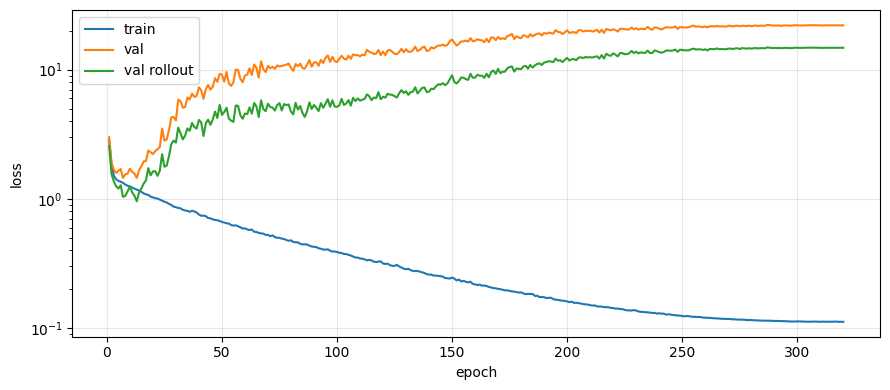

In [13]:
plt.figure(figsize=(9, 4))
plt.semilogy(history['epoch'], history['train_loss'], label='train')
plt.semilogy(history['epoch'], history['val_loss'], label='val')
if 'val_rollout_loss' in history.columns:
    plt.semilogy(history['epoch'], history['val_rollout_loss'], label='val rollout')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'training_curve.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 9. One-Step Test Evaluation

In [14]:
@torch.no_grad()
def predict_delta_physical(model, df):
    X = torch.tensor(df[FEAT_COLS].values, dtype=torch.float32).to(device)
    Xn = (X - model.Xm) / model.Xs
    dn = model(Xn)
    dp = model.denorm_delta(dn, add_mean=True)
    return dp.cpu().numpy()


def one_step_metrics(model, df, name):
    pred = predict_delta_physical(model, df)
    true = df[TGT_COLS].values
    rows = []
    for i, col in enumerate(TGT_COLS):
        err = pred[:, i] - true[:, i]
        rows.append({
            'split': name,
            'target': col,
            'rmse': float(np.sqrt(np.mean(err**2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(true[:, i])),
        })
    return pd.DataFrame(rows)


metrics_one = pd.concat([
    one_step_metrics(model, train_df, 'train'),
    one_step_metrics(model, val_df, 'val'),
    one_step_metrics(model, test_df, 'test'),
], ignore_index=True)
metrics_one.to_csv(os.path.join(SAVE_DIR, 'one_step_metrics.csv'), index=False)
metrics_one

,split,target,rmse,mae,std_true
0,train,dh,0.027309,0.019202,0.212521
1,train,dV,0.003543,0.002543,0.052706
2,train,dtheta,0.000055,0.000037,0.001011
3,train,dq,0.003266,0.002285,0.004438
4,val,dh,0.041871,0.023037,0.272985
5,val,dV,0.004727,0.003179,0.068393
6,val,dtheta,0.000080,0.000049,0.001111
7,val,dq,0.003589,0.002282,0.004689
8,test,dh,0.028153,0.019406,0.220164
9,test,dV,0.003965,0.002897,0.051887


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/one_step_scatter.png


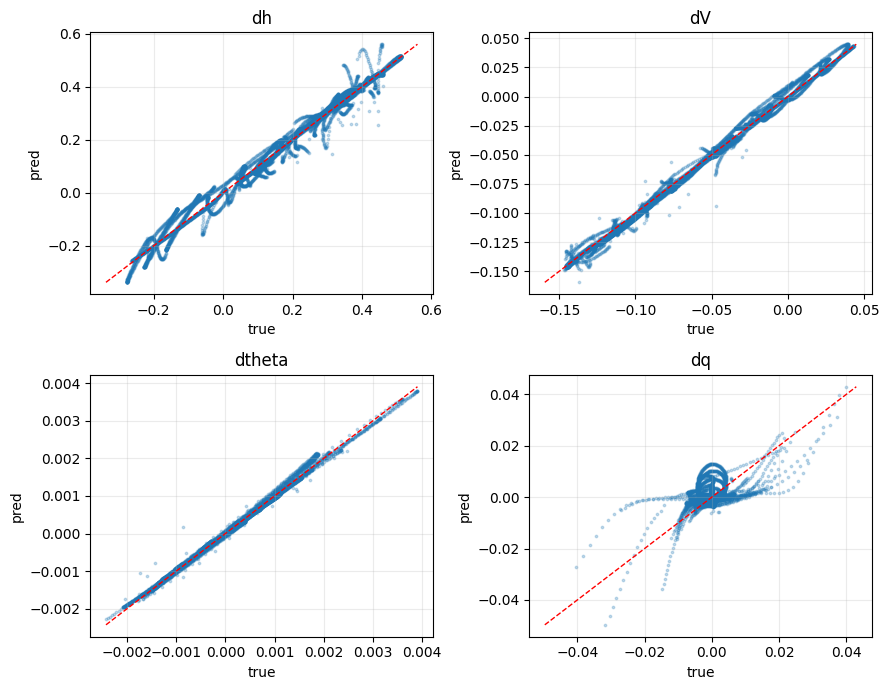

In [15]:
pred_test = predict_delta_physical(model, test_df)
true_test = test_df[TGT_COLS].values
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, col, i in zip(axes.ravel(), TGT_COLS, range(4)):
    ax.scatter(true_test[:, i], pred_test[:, i], s=3, alpha=0.25)
    lo = min(true_test[:, i].min(), pred_test[:, i].min())
    hi = max(true_test[:, i].max(), pred_test[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(col)
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'one_step_scatter.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 10. Multi-Step Rollout Evaluation

For MPC, rollout accuracy matters more than one-step accuracy. This section compares a recursive PINN rollout against a JSBSim trajectory.

In [16]:
def rollout_pinn(model, init_state, elevator_seq):
    model.eval()
    elev_seq = np.asarray(elevator_seq, dtype=np.float32)
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()

    if len(elev_seq) == 0:
        return np.asarray(states)

    # Contract: init_state is the JSBSim state after applying elev_seq[0].
    # Each prediction step uses prev_elevator=elev_seq[k-1], elevator=elev_seq[k].
    prev_elev = float(elev_seq[0])
    for k in range(1, len(elev_seq)):
        elev = float(elev_seq[k])
        delevator = elev - prev_elev
        x = np.array([current[0], current[1], current[2], current[3], elev, prev_elev, delevator], dtype=np.float32)
        xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
        xn = (xt - model.Xm) / model.Xs
        with torch.no_grad():
            dn = model(xn)
            delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
        current = current + delta
        states.append(current.copy())
        prev_elev = elev
    return np.asarray(states)


def jsbsim_trajectory(init_alt, init_speed, init_pitch, elevator_seq):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    elev_seq = np.asarray(elevator_seq, dtype=np.float32)

    if len(elev_seq) == 0:
        return np.asarray([read_state(fdm)])

    # Warm-start with the first command, then record the aligned initial state.
    prev_elev = float(elev_seq[0])
    fdm['fcs/elevator-cmd-norm'] = prev_elev
    fdm.run()
    states = [read_state(fdm).copy()]

    for k in range(1, len(elev_seq)):
        elev = float(elev_seq[k])
        fdm['fcs/elevator-cmd-norm'] = elev
        fdm.run()
        states.append(read_state(fdm).copy())
    return np.asarray(states)


def make_elevator_signal_rng(n_steps, mode, rng):
    t = np.arange(n_steps) * DT
    if mode == 'smooth_random':
        elev = np.zeros(n_steps, dtype=np.float32)
        for i in range(1, n_steps):
            elev[i] = 0.94 * elev[i-1] + 0.06 * rng.uniform(-0.45, 0.45)
        return np.clip(elev, -0.45, 0.45)
    if mode == 'sine':
        amp = rng.uniform(0.08, 0.28)
        freq = rng.uniform(0.03, 0.18)
        phase = rng.uniform(0, 2*np.pi)
        return (amp * np.sin(2*np.pi*freq*t + phase)).astype(np.float32)
    if mode == 'steps':
        elev = np.zeros(n_steps, dtype=np.float32)
        hold = int(rng.integers(25, 100))
        val = 0.0
        for i in range(n_steps):
            if i % hold == 0:
                val = rng.uniform(-0.40, 0.40)
                hold = int(rng.integers(25, 120))
            elev[i] = val
        return elev
    if mode == 'chirp':
        amp = rng.uniform(0.08, 0.26)
        f0, f1 = 0.03, rng.uniform(0.18, 0.45)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return (amp * np.sin(phase)).astype(np.float32)
    if mode == 'doublet':
        elev = np.zeros(n_steps, dtype=np.float32)
        k = int(rng.integers(30, max(31, n_steps - 120)))
        amp = rng.uniform(0.15, 0.35) * rng.choice([-1.0, 1.0])
        width = int(rng.integers(12, 35))
        elev[k:k+width] = amp
        elev[k+width:k+2*width] = -amp
        return elev
    raise ValueError(mode)


def build_fixed_rollout_cases(n_cases, n_steps, seed):
    rng = np.random.default_rng(seed)
    modes = ['smooth_random', 'sine', 'steps', 'chirp', 'doublet']
    cases = []
    for case in range(n_cases):
        mode = modes[case % len(modes)]
        elev = make_elevator_signal_rng(n_steps, mode, rng)
        init_alt = float(rng.uniform(2300, 6000))
        init_speed = float(rng.uniform(85, 115))
        init_pitch = float(rng.uniform(-5, 8))
        actual = jsbsim_trajectory(init_alt, init_speed, init_pitch, elev)
        cases.append({
            'case': case,
            'mode': mode,
            'init_alt': init_alt,
            'init_speed': init_speed,
            'init_pitch': init_pitch,
            'elevator': elev,
            'actual': actual,
        })
    return cases


def eval_rollout_cases(model, cases):
    rows = []
    packed = []
    for item in cases:
        elev = item['elevator']
        actual = item['actual']
        pred = rollout_pinn(model, actual[0], elev)

        n = min(len(actual), len(pred))
        actual_cmp = actual[:n]
        pred_cmp = pred[:n]
        err = pred_cmp - actual_cmp
        row = {'case': item['case'], 'mode': item['mode']}
        for i, col in enumerate(STATE_COLS):
            row[f'{col}_rmse'] = float(np.sqrt(np.mean(err[:, i]**2)))
            row[f'{col}_max_abs'] = float(np.max(np.abs(err[:, i])))
        rows.append(row)
        packed.append((item['mode'], elev, actual_cmp, pred_cmp))
    return pd.DataFrame(rows), packed


rollout_val_cases = build_fixed_rollout_cases(N_ROLLOUT_VAL_CASES, ROLLOUT_STEPS, ROLLOUT_VAL_SEED)
rollout_test_cases = build_fixed_rollout_cases(N_ROLLOUT_TEST_CASES, ROLLOUT_STEPS, ROLLOUT_TEST_SEED)

rollout_metrics, rollout_cases = eval_rollout_cases(model, rollout_val_cases)
rollout_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_initial_val.csv'), index=False)
rollout_metrics

,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs
0,0,smooth_random,1.084972,2.381104,0.328955,0.487320,0.020566,0.038766,0.057491,0.086992
1,1,sine,2.345335,4.155518,0.999924,1.462128,0.044858,0.104977,0.137201,0.177394
2,2,steps,3.741976,7.574707,0.808913,1.478638,0.036325,0.058422,0.101031,0.201225
3,3,chirp,1.285783,1.791260,0.185424,0.307632,0.016431,0.029723,0.057392,0.110839
4,4,doublet,1.437040,2.177246,0.427350,0.613739,0.018591,0.033386,0.060590,0.117455
5,5,smooth_random,1.739696,2.334717,0.603080,0.787628,0.018651,0.035084,0.072471,0.120324
6,6,sine,1.871689,3.733887,0.419248,0.665894,0.029238,0.057624,0.091142,0.131236
7,7,steps,1.623493,3.119141,0.299691,0.504959,0.024866,0.051580,0.105896,0.236468


## 10-1. Automatic q-aware Continue Training

After the initial training pass, this section checks rollout metrics on a fixed validation rollout set. If `q_rmse` or other target metrics are above the thresholds, the model continues training in chunks. Only checkpoints that improve the fixed-set rollout score are kept.

In [17]:
def rollout_summary_score(metrics_df):
    h = float(metrics_df['h_rmse'].mean())
    theta = float(metrics_df['theta_rmse'].mean())
    q = float(metrics_df['q_rmse'].mean())
    score = h / TARGET_H_RMSE_FT + theta / TARGET_THETA_RMSE_RAD + q / TARGET_Q_RMSE_RAD_S
    ok = (h <= TARGET_H_RMSE_FT) and (theta <= TARGET_THETA_RMSE_RAD) and (q <= TARGET_Q_RMSE_RAD_S)
    return score, ok, {'h_rmse_mean': h, 'theta_rmse_mean': theta, 'q_rmse_mean': q}


auto_log = []
score, ok, summary = rollout_summary_score(rollout_metrics)
best_rollout_score = score
best_rollout_summary = dict(summary)
best_rollout_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
best_cycle = 0
print('Initial fixed rollout summary:', summary, 'score=', round(score, 3), 'ok=', ok)

if AUTO_TRAIN:
    current_lr = BEST_PARAMS.get('lr', LR)
    for cycle in range(1, AUTO_MAX_CYCLES + 1):
        if ok:
            print(f'[PASS] target reached before cycle {cycle}')
            break

        # Always restart from the best rollout checkpoint before trying another chunk.
        model.load_state_dict({k: v.to(device) for k, v in best_rollout_state.items()})

        current_lr *= AUTO_LR_DECAY
        chunk_params = dict(BEST_PARAMS)
        chunk_params['epochs'] = AUTO_CHUNK_EPOCHS
        chunk_params['lr'] = current_lr
        chunk_params['target_weights'] = TARGET_WEIGHTS

        print(f'\n[AUTO] cycle {cycle}/{AUTO_MAX_CYCLES} | lr={current_lr:.2e} | epochs={AUTO_CHUNK_EPOCHS}')
        model, hist_extra, val_extra = train_model(chunk_params, verbose=True, initial_model=model)

        extra = hist_extra.copy()
        extra['auto_cycle'] = cycle
        history = pd.concat([history, extra], ignore_index=True)

        rollout_metrics, rollout_cases = eval_rollout_cases(model, rollout_val_cases)
        score, ok, summary = rollout_summary_score(rollout_metrics)
        row = {'cycle': cycle, 'score': score, 'ok': ok, **summary}
        auto_log.append(row)
        print('[AUTO] fixed rollout summary:', row)

        if score < best_rollout_score:
            best_rollout_score = score
            best_rollout_summary = dict(summary)
            best_rollout_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_cycle = cycle
            print('[AUTO] best rollout checkpoint updated')
        else:
            print('[AUTO] no fixed-rollout improvement; keeping previous best checkpoint')

    model.load_state_dict({k: v.to(device) for k, v in best_rollout_state.items()})

rollout_val_metrics, rollout_val_packed = eval_rollout_cases(model, rollout_val_cases)
rollout_test_metrics, rollout_cases = eval_rollout_cases(model, rollout_test_cases)
rollout_metrics = rollout_test_metrics
score_test, ok_test, summary_test = rollout_summary_score(rollout_test_metrics)

metrics_one = pd.concat([
    one_step_metrics(model, train_df, 'train'),
    one_step_metrics(model, val_df, 'val'),
    one_step_metrics(model, test_df, 'test'),
], ignore_index=True)

AUTO_SUMMARY = {
    'best_cycle': int(best_cycle),
    'best_rollout_score_val': float(best_rollout_score),
    'best_h_rmse_mean_val': float(best_rollout_summary['h_rmse_mean']),
    'best_theta_rmse_mean_val': float(best_rollout_summary['theta_rmse_mean']),
    'best_q_rmse_mean_val': float(best_rollout_summary['q_rmse_mean']),
    'final_rollout_score_test': float(score_test),
    'final_h_rmse_mean_test': float(summary_test['h_rmse_mean']),
    'final_theta_rmse_mean_test': float(summary_test['theta_rmse_mean']),
    'final_q_rmse_mean_test': float(summary_test['q_rmse_mean']),
    'test_targets_met': bool(ok_test),
    'auto_cycles_run': int(len(auto_log)),
    'auto_restart_policy': 'restart_each_cycle_from_best_rollout_checkpoint',
}

auto_log_df = pd.DataFrame(auto_log)
auto_log_df.to_csv(os.path.join(SAVE_DIR, 'auto_training_log.csv'), index=False)
history.to_csv(os.path.join(SAVE_DIR, 'training_history_auto.csv'), index=False)
metrics_one.to_csv(os.path.join(SAVE_DIR, 'one_step_metrics_auto.csv'), index=False)
rollout_val_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_auto_val.csv'), index=False)
rollout_test_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_auto_test.csv'), index=False)

print('\nFinal one-step metrics:')
display(metrics_one)
print('\nFinal fixed validation rollout metrics:')
display(rollout_val_metrics)
print('\nFinal fixed test rollout metrics:')
display(rollout_test_metrics)
print('\nAuto summary:')
print(json.dumps(AUTO_SUMMARY, indent=2))
print('\nAuto training log:')
display(auto_log_df)

Initial fixed rollout summary: {'h_rmse_mean': 1.8912479430437088, 'theta_rmse_mean': 0.026190875563770533, 'q_rmse_mean': 0.08540184143930674} score= 4.206 ok= False

[AUTO] cycle 1/8 | lr=4.32e-04 | epochs=120
epoch    1/120 | train=1.17170e+00 | val=1.67399e+00 | data=1.52138e+00 | phys=3.40889e-01 | roll=1.18521e+00
epoch   12/120 | train=9.94919e-01 | val=2.81656e+00 | data=2.57366e+00 | phys=3.53899e-01 | roll=2.07509e+00
epoch   24/120 | train=8.43048e-01 | val=4.79623e+00 | data=4.45729e+00 | phys=3.69127e-01 | roll=3.02024e+00
epoch   36/120 | train=7.44913e-01 | val=6.87557e+00 | data=6.46139e+00 | phys=3.86542e-01 | roll=3.75534e+00
epoch   48/120 | train=6.74672e-01 | val=7.59631e+00 | data=7.12533e+00 | phys=3.91214e-01 | roll=4.31864e+00
epoch   60/120 | train=6.17365e-01 | val=8.73287e+00 | data=8.23621e+00 | phys=3.91592e-01 | roll=4.57496e+00
epoch   72/120 | train=5.75920e-01 | val=9.42435e+00 | data=8.90430e+00 | phys=3.93776e-01 | roll=4.80677e+00
epoch   84/120 | t

,split,target,rmse,mae,std_true
0,train,dh,0.024512,0.017536,0.212521
1,train,dV,0.003373,0.002345,0.052706
2,train,dtheta,0.000044,0.000029,0.001011
3,train,dq,0.003120,0.002157,0.004438
4,val,dh,0.033331,0.021982,0.272985
5,val,dV,0.005260,0.003625,0.068393
6,val,dtheta,0.000081,0.000048,0.001111
7,val,dq,0.004111,0.002604,0.004689
8,test,dh,0.025864,0.018248,0.220164
9,test,dV,0.003296,0.002227,0.051887



Final fixed validation rollout metrics:


,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs
0,0,smooth_random,1.163537,2.976562,0.149731,0.311890,0.016377,0.029284,0.048830,0.085463
1,1,sine,2.290956,3.385498,0.689220,1.066162,0.028493,0.044206,0.099752,0.169396
2,2,steps,4.110111,7.504883,0.777712,1.291245,0.031840,0.053143,0.097021,0.192490
3,3,chirp,0.908780,1.312012,0.173323,0.286209,0.016826,0.029692,0.056913,0.113534
4,4,doublet,1.087994,1.801270,0.211348,0.333267,0.015357,0.024405,0.054280,0.108025
5,5,smooth_random,1.533199,2.083252,0.428048,0.584656,0.018690,0.035963,0.064933,0.123391
6,6,sine,1.209670,2.495117,0.201175,0.298828,0.021753,0.035862,0.075181,0.139297
7,7,steps,2.035438,3.545898,0.304090,0.557495,0.024838,0.052868,0.102619,0.216897



Final fixed test rollout metrics:


,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs
0,0,smooth_random,1.826870,2.194336,0.422506,0.547134,0.012289,0.024205,0.044878,0.083306
1,1,sine,1.660741,4.607666,0.559541,1.423325,0.037719,0.075187,0.050030,0.071096
2,2,steps,2.494281,4.439941,0.073791,0.134171,0.005655,0.012944,0.035734,0.085354
3,3,chirp,1.553729,2.056641,0.390455,0.515503,0.012728,0.020483,0.046235,0.074394
4,4,doublet,2.068687,2.656494,0.405627,0.560730,0.019363,0.032943,0.049424,0.098463
5,5,smooth_random,1.306981,3.072266,0.196714,0.288315,0.018987,0.030562,0.051137,0.088806
6,6,sine,1.759932,5.115967,0.312044,0.916031,0.033104,0.069884,0.052598,0.078873
7,7,steps,1.775192,2.999512,0.337437,0.604980,0.038779,0.059120,0.132022,0.229402



Auto summary:
{
  "best_cycle": 2,
  "best_rollout_score_val": 3.7312094493665633,
  "best_h_rmse_mean_val": 1.7924606651067734,
  "best_theta_rmse_mean_val": 0.021771821076981723,
  "best_q_rmse_mean_val": 0.07494132732972503,
  "final_rollout_score_test": 3.3804810575933923,
  "final_h_rmse_mean_test": 1.8058014810085297,
  "final_theta_rmse_mean_test": 0.02232795429881662,
  "final_q_rmse_mean_test": 0.05775728542357683,
  "test_targets_met": false,
  "auto_cycles_run": 8,
  "auto_restart_policy": "restart_each_cycle_from_best_rollout_checkpoint"
}

Auto training log:


,cycle,score,ok,h_rmse_mean,theta_rmse_mean,q_rmse_mean
0,1,3.967779,False,1.913416,0.023079,0.079604
1,2,3.731209,False,1.792461,0.021772,0.074941
2,3,4.042319,False,2.089641,0.023551,0.076823
3,4,4.047450,False,1.928575,0.024331,0.080482
4,5,3.994972,False,1.976058,0.023291,0.078568
5,6,3.857307,False,1.843187,0.022747,0.077339
6,7,3.976720,False,1.895817,0.023657,0.079495
7,8,3.875796,False,1.855348,0.022754,0.077794


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/rollout_validation.png


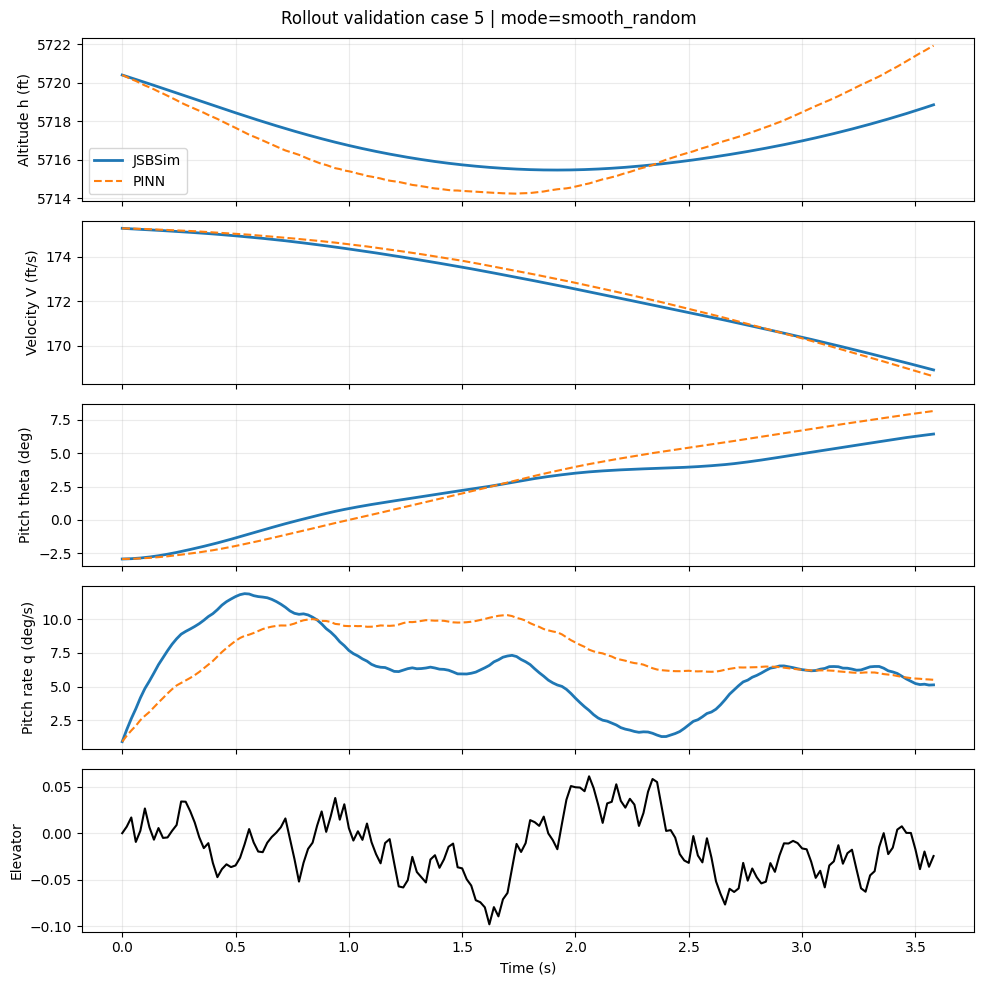

In [19]:
case_idx = int(rollout_metrics['h_rmse'].idxmin()) if len(rollout_metrics) else 0
mode, elev, actual, pred = rollout_cases[case_idx]
t = np.arange(len(actual)) * DT

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
labels = ['Altitude h (ft)', 'Velocity V (ft/s)', 'Pitch theta (deg)', 'Pitch rate q (deg/s)']
for i, ax in enumerate(axes[:4]):
    a = actual[:, i].copy()
    p = pred[:, i].copy()
    if i in [2, 3]:
        a = np.degrees(a)
        p = np.degrees(p)
    ax.plot(t, a, label='JSBSim', lw=2)
    ax.plot(t, p, '--', label='PINN', lw=1.5)
    ax.set_ylabel(labels[i])
    ax.grid(True, alpha=0.25)
axes[4].plot(t[0:], elev, color='k')
axes[4].set_ylabel('Elevator')
axes[4].set_xlabel('Time (s)')
axes[4].grid(True, alpha=0.25)
axes[0].legend()
fig.suptitle(f'Rollout validation case {case_idx} | mode={mode}')
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'rollout_validation.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 11. Save PINN Checkpoint

The saved checkpoint can be loaded later from the MPC notebook.

In [20]:
checkpoint = {
    'model_state': model.state_dict(),
    'stats': {k: v.cpu() for k, v in stats.items()},
    'config': CONFIG,
    'best_params': BEST_PARAMS,
    'auto_summary': AUTO_SUMMARY,
    'auto_training_log': auto_log_df.to_dict(orient='records'),
    'feature_cols': FEAT_COLS,
    'target_cols': TGT_COLS,
    'state_cols': STATE_COLS,
    'input_cols': INPUT_COLS,
    'dt': DT,
    'one_step_metrics': metrics_one.to_dict(orient='records'),
    'rollout_val_metrics': rollout_val_metrics.to_dict(orient='records'),
    'rollout_test_metrics': rollout_test_metrics.to_dict(orient='records'),
    'rollout_metrics': rollout_test_metrics.to_dict(orient='records'),
}
ckpt_path = os.path.join(SAVE_DIR, 'pinn_dynamics_c172_2d_v5_2_warmstart.pt')
torch.save(checkpoint, ckpt_path)

with open(os.path.join(SAVE_DIR, 'pinn_training_summary_v5_2_warmstart.json'), 'w') as f:
    json.dump({
        'config': CONFIG,
        'best_params': BEST_PARAMS,
        'best_val_loss_initial_training': float(best_val),
        'auto_summary': AUTO_SUMMARY,
        'checkpoint': ckpt_path,
    }, f, indent=2)

print('Saved checkpoint:', ckpt_path)
print('Saved summary:', os.path.join(SAVE_DIR, 'pinn_training_summary_v5_2_warmstart.json'))


Saved checkpoint: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_2_warmstart.pt
Saved summary: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_training_summary_v5_2_warmstart.json


## 12. Loading Example for MPC Notebook

In [ ]:
# Minimal loading example for a future MPC notebook.
# Note: v5.2 uses augmented inputs:
# [h, V, theta, q, elevator, prev_elevator, delevator]
# The rollout/MPC code should warm-start the previous elevator command exactly like this notebook.
#
# checkpoint = torch.load('/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_2_warmstart.pt', map_location=device)
# stats_loaded = checkpoint['stats']
# model_loaded = PhysicsPINN(
#     hidden_dim=checkpoint['best_params']['hidden_dim'],
#     n_layers=checkpoint['best_params']['n_layers'],
#     stats=stats_loaded,
# ).to(device)
# model_loaded.load_state_dict(checkpoint['model_state'])
# model_loaded.eval()
# print('Loaded v5.2 warm-start aligned PINN dynamics model')